# Universidad del Valle de Guatemala
**Facultad de Ingeniería — Ciencia de la Computación y Tecnologías de la Información**

**CC2017 - Modelación y Simulación** · Ciclo 2, 2026

# Práctica 2

## Ejercicio 1

Sea $X$ una variable aleatoria exponencial con media 1. Proporcione un algoritmo eficiente para simular una variable aleatoria cuya distribución es la distribución condicional de $X$ dado que $X < 0.05$. Es decir, su función de densidad es

$$f(x) = \frac{e^{-x}}{1-e^{-0.05}}, \quad 0 < x < 0.05$$

Genere 1000 de estas variables y utilícelas para estimar $E[X \mid X < 0.05]$. Luego determine el valor exacto de $E[X \mid X < 0.05]$.

In [1]:
import random
import math

# --- Parámetros del problema ---
limite_de_truncamiento = 0.05      
numero_de_muestras_a_generar = 1000 

# Fijar una semilla 
random.seed(42)

### Deducir la fórmula (transformada inversa)



$$f(x) = \frac{e^{-x}}{1-e^{-0.05}}, \quad 0 < x < 0.05$$


$$F(x) = \int_0^x f(t)\,dt = \frac{1-e^{-x}}{1-e^{-0.05}}$$


$$u = \frac{1-e^{-x}}{1-e^{-0.05}} \;\Longrightarrow\; X = -\ln\!\big(1 - U(1-e^{-0.05})\big)$$


In [2]:
lista_de_variables_truncadas = []

for indice_de_muestra in range(numero_de_muestras_a_generar):

    numero_aleatorio_uniforme = random.random() 

    # Aplicamos la fórmula deducida
    factor_de_escala = 1 - math.exp(-limite_de_truncamiento) 
    probabilidad_reescalada = numero_aleatorio_uniforme * factor_de_escala
    valor_exponencial_truncado = -math.log(1 - probabilidad_reescalada)

    lista_de_variables_truncadas.append(valor_exponencial_truncado)

valor_minimo_generado = min(lista_de_variables_truncadas)
valor_maximo_generado = max(lista_de_variables_truncadas)

print(f"Se generaron {len(lista_de_variables_truncadas)} muestras")
print(f"Rango de las muestras generadas: [{valor_minimo_generado:.5f}, {valor_maximo_generado:.5f}]")
print(f"(deben estar dentro de [0, {limite_de_truncamiento}])")

Se generaron 1000 muestras
Rango de las muestras generadas: [0.00002, 0.05000]
(deben estar dentro de [0, 0.05])


### Estimar $E[X \mid X < 0.05]$ promediando 

In [3]:
suma_de_todas_las_muestras = sum(lista_de_variables_truncadas)
esperanza_estimada_por_simulacion = suma_de_todas_las_muestras / numero_de_muestras_a_generar

print(f"Estimación por simulación de E[X | X < 0.05]: {esperanza_estimada_por_simulacion:.6f}")

Estimación por simulación de E[X | X < 0.05]: 0.025419


### Calcular el valor exacto 

$$E[X\mid X<0.05] = \int_0^{0.05} x\, f(x)\, dx = \frac{\displaystyle\int_0^{0.05} x\, e^{-x}\,dx}{1-e^{-0.05}}$$



$$E[X\mid X<0.05] = \frac{1-(1.05)\,e^{-0.05}}{1-e^{-0.05}}$$



In [4]:

numerador_de_la_formula_exacta = 1 - (1 + limite_de_truncamiento) * math.exp(-limite_de_truncamiento)
denominador_de_la_formula_exacta = 1 - math.exp(-limite_de_truncamiento)
esperanza_exacta = numerador_de_la_formula_exacta / denominador_de_la_formula_exacta

error_absoluto_de_la_simulacion = abs(esperanza_estimada_por_simulacion - esperanza_exacta)

print(f"Valor exacto de E[X | X < 0.05]:            {esperanza_exacta:.6f}")
print(f"Estimación por simulación (1000 muestras):  {esperanza_estimada_por_simulacion:.6f}")
print(f"Error absoluto de la simulación:             {error_absoluto_de_la_simulacion:.6f}")

Valor exacto de E[X | X < 0.05]:            0.024792
Estimación por simulación (1000 muestras):  0.025419
Error absoluto de la simulación:             0.000628


## Ejercicio 2 (Método de composición)

Suponga que es relativamente fácil generar variables aleatorias a partir de cualquiera de las distribuciones $F_i$, $i=1,\ldots,n$. ¿Cómo podríamos generar una variable aleatoria con función de distribución

$$F(x) = \sum_{i=1}^{n} p_i F_i(x)$$

donde los $p_i$, $i=1,\ldots,n$, son números no negativos cuya suma es 1?

No podemos generar $X$ invirtiendo $F(x)$ directamente porque es una fórmula complicada (una mezcla de varias distribuciones a la vez). Pero podemos pensarlo así: en cada ocasión, $X$ en realidad **proviene de una sola** de esas $n$ distribuciones no de una combinación rara de todas al mismo tiempo  solo que no sabemos de cuál hasta que se decide al azar, con las proporciones que dan los $p_i$. Entonces basta con **simular ese mismo mecanismo de dos pasos**: primero elegir al azar cuál $F_i$ le toca a $X$ esta vez (usando los $p_i$ como probabilidades de elegir cada una), y después generar el valor real usando solo esa $F_i$ ya elegida lo cual es fácil, porque cada $F_i$ por separado ya sabemos generarla.

**Algoritmo (método de composición):**

1. Genera un índice aleatorio $I \in \{1,\dots,n\}$ tal que $P(I=i) = p_i$. (Con transformada inversa discreta: genera $U\sim\text{Unif}(0,1)$ y parte $(0,1)$ en $n$ segmentos consecutivos de anchos $p_1,\dots,p_n$; $I=i$ si $U$ cae en el $i$-ésimo segmento.)
2. Dado el $I=i$ obtenido, genera $X$ con distribución $F_i$ (con el método que corresponda a esa $F_i$ típicamente transformada inversa).
3. Devuelve $X$.

## Ejercicio 3

Utilizando el resultado del Ejercicio 2, proporcione algoritmos para generar variables aleatorias a partir de las siguientes distribuciones.

### (a)

$$F(x) = \frac{x+x^3+x^5}{3}, \quad 0 \le x \le 1$$

Repartiendo el denominador entre los tres términos, la distribución ya queda escrita como una mezcla:

$$F(x) = \frac{1}{3}\,x \;+\; \frac{1}{3}\,x^3 \;+\; \frac{1}{3}\,x^5$$



Cada componente es de la forma $F_i(x)=x^{k}$ en $(0,1)$, que se genera por transformada inversa como $X=U^{1/k}$, ya que

$$P\!\left(U^{1/k}\le x\right) = P\!\left(U \le x^{k}\right) = x^{k}$$

con exponentes $k_1=1$, $k_2=3$, $k_3=5$.

In [5]:
import random

random.seed(42)

pesos_de_cada_componente = [1/3, 1/3, 1/3]
exponentes_de_cada_componente = [1, 3, 5]   # F_i(x) = x^k, se genera como U^(1/k)

def generar_variable_inciso_a():
    numero_aleatorio_para_elegir_componente = random.random()

    # Recorremos los pesos acumulados para ver en qué segmento de (0,1) cayó
    peso_acumulado = 0.0
    indice_del_componente_elegido = 0

    for indice_candidato, peso_del_componente in enumerate(pesos_de_cada_componente):
        peso_acumulado += peso_del_componente
        if numero_aleatorio_para_elegir_componente < peso_acumulado:
            indice_del_componente_elegido = indice_candidato
            break

    exponente_del_componente_elegido = exponentes_de_cada_componente[indice_del_componente_elegido]

    numero_aleatorio_para_generar_valor = random.random()
    valor_generado = numero_aleatorio_para_generar_valor ** (1 / exponente_del_componente_elegido)

    return valor_generado

numero_de_muestras = 10000
muestras_del_inciso_a = [generar_variable_inciso_a() for _ in range(numero_de_muestras)]

print(f"Se generaron {len(muestras_del_inciso_a)} muestras")
print(f"Rango: [{min(muestras_del_inciso_a):.5f}, {max(muestras_del_inciso_a):.5f}]")
print(f"Media de las muestras: {sum(muestras_del_inciso_a)/numero_de_muestras:.5f}")

Se generaron 10000 muestras
Rango: [0.00004, 0.99992]
Media de las muestras: 0.69620


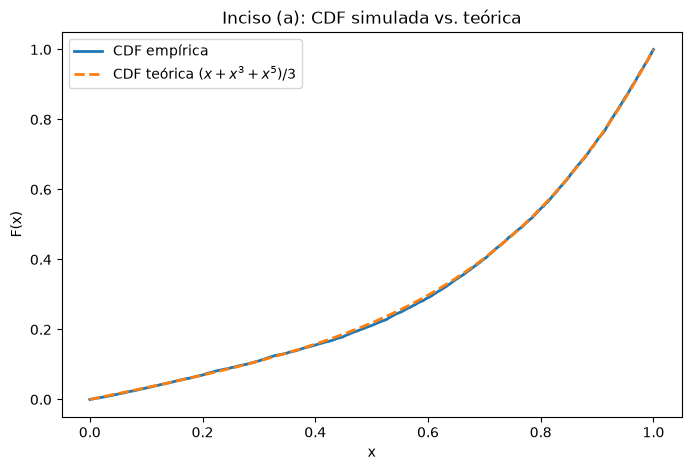

In [6]:
import numpy as np
import matplotlib.pyplot as plt

muestras_ordenadas = np.sort(muestras_del_inciso_a)
cdf_empirica = np.arange(1, numero_de_muestras + 1) / numero_de_muestras

puntos_x = np.linspace(0, 1, 300)
cdf_teorica = (puntos_x + puntos_x**3 + puntos_x**5) / 3

plt.figure(figsize=(8, 5))
plt.plot(muestras_ordenadas, cdf_empirica, linewidth=2, label="CDF empírica")
plt.plot(puntos_x, cdf_teorica, linestyle="--", linewidth=2, label="CDF teórica $(x+x^3+x^5)/3$")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Inciso (a): CDF simulada vs. teórica")
plt.legend()
plt.show()

### (b)

$$F(x) = \begin{cases} \dfrac{1-e^{-2x}+2x}{3}, & 0 < x < 1 \\[6pt] \dfrac{3-e^{-2x}}{3}, & 1 < x < \infty \end{cases}$$

Separando en cada tramo el término con $e^{-2x}$ del resto:

$$0 < x < 1: \quad F(x) - \tfrac{1}{3}\left(1-e^{-2x}\right) = \frac{2x}{3}$$

$$x > 1: \quad F(x) - \tfrac{1}{3}\left(1-e^{-2x}\right) = \frac{3-e^{-2x}}{3} - \frac{1-e^{-2x}}{3} = \frac{2}{3}$$

Lo que queda vale $\tfrac{2}{3}x$ en $(0,1)$ y $\tfrac{2}{3}$ para $x \ge 1$, es decir $\tfrac{2}{3}H(x)$ con $H$ la CDF de una $\text{Unif}(0,1)$. Entonces

$$F(x) = \frac{1}{3}\underbrace{\left(1-e^{-2x}\right)}_{\text{Exp}(2)} \;+\; \frac{2}{3}\underbrace{H(x)}_{\text{Unif}(0,1)}$$

con $n=2$, pesos $p_1=\tfrac{1}{3}$, $p_2=\tfrac{2}{3}$ (suman 1).

Cada componente se genera por transformada inversa:

$$X_1 = -\frac{\ln U}{2} \quad (\text{Exp de tasa } 2), \qquad X_2 = U \quad (\text{Unif}(0,1))$$

In [7]:
import random
import math

random.seed(42)

peso_de_la_exponencial = 1/3
tasa_de_la_exponencial = 2

def generar_variable_inciso_b():
    numero_aleatorio_para_elegir_componente = random.random()
    numero_aleatorio_para_generar_valor = random.random()

    if numero_aleatorio_para_elegir_componente < peso_de_la_exponencial:
        valor_generado = -math.log(numero_aleatorio_para_generar_valor) / tasa_de_la_exponencial
    else:
        valor_generado = numero_aleatorio_para_generar_valor

    return valor_generado

numero_de_muestras = 10000
muestras_del_inciso_b = [generar_variable_inciso_b() for _ in range(numero_de_muestras)]

print(f"Se generaron {len(muestras_del_inciso_b)} muestras")
print(f"Rango: [{min(muestras_del_inciso_b):.5f}, {max(muestras_del_inciso_b):.5f}]")
print(f"Media de las muestras: {sum(muestras_del_inciso_b)/numero_de_muestras:.5f}")

Se generaron 10000 muestras
Rango: [0.00009, 5.12002]
Media de las muestras: 0.49703


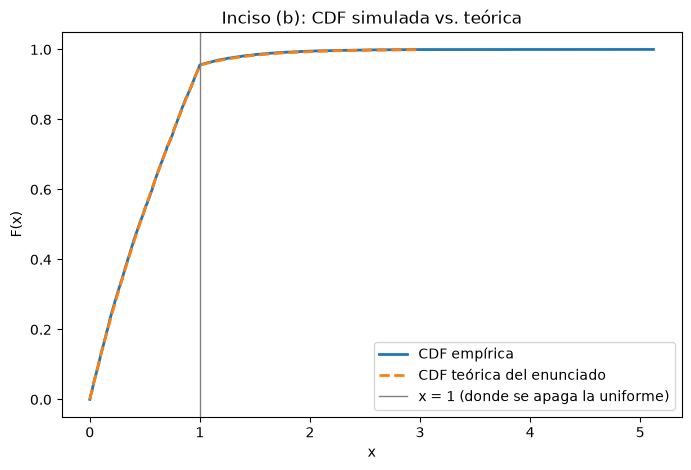

In [8]:
import numpy as np
import matplotlib.pyplot as plt

muestras_ordenadas = np.sort(muestras_del_inciso_b)
cdf_empirica = np.arange(1, numero_de_muestras + 1) / numero_de_muestras

puntos_x = np.linspace(0, 3, 300)
cdf_teorica = np.where(
    puntos_x < 1,
    (1 - np.exp(-2 * puntos_x) + 2 * puntos_x) / 3,
    (3 - np.exp(-2 * puntos_x)) / 3,
)

plt.figure(figsize=(8, 5))
plt.plot(muestras_ordenadas, cdf_empirica, linewidth=2, label="CDF empírica")
plt.plot(puntos_x, cdf_teorica, linestyle="--", linewidth=2, label="CDF teórica del enunciado")
plt.axvline(1, color="gray", linewidth=1, label="x = 1 (donde se apaga la uniforme)")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Inciso (b): CDF simulada vs. teórica")
plt.legend()
plt.show()

### (c)

$$F(x) = \sum_{i=1}^{n} \alpha_i x^i, \quad 0 \le x \le 1, \quad \text{donde } \alpha_i \ge 0,\ \sum_{i=1}^{n} \alpha_i = 1$$

La distribución ya viene escrita como mezcla: los pesos son $p_i = \alpha_i$ (no negativos y suman 1) y las componentes son $F_i(x) = x^i$ en $(0,1)$.

Igual que en el inciso (a), cada componente se genera por transformada inversa con $X = U^{1/i}$, ya que

$$P\!\left(U^{1/i}\le x\right) = P\!\left(U \le x^{i}\right) = x^{i}$$

La diferencia con (a) es que aquí $n$ y los pesos son arbitrarios, y el exponente coincide con el índice. De hecho (a) es el caso particular $n=5$ con $\alpha_1=\alpha_3=\alpha_5=\tfrac{1}{3}$ y $\alpha_2=\alpha_4=0$.

El algoritmo de abajo recibe cualquier lista de $\alpha_i$.

In [9]:
import random

random.seed(42)

def generar_variable_inciso_c(alfas_de_cada_componente):
    numero_aleatorio_para_elegir_componente = random.random()

    peso_acumulado = 0.0
    indice_del_componente_elegido = 0

    for indice_candidato, alfa_del_componente in enumerate(alfas_de_cada_componente):
        peso_acumulado += alfa_del_componente
        if numero_aleatorio_para_elegir_componente < peso_acumulado:
            indice_del_componente_elegido = indice_candidato
            break

    exponente_del_componente_elegido = indice_del_componente_elegido + 1  # el exponente es i

    numero_aleatorio_para_generar_valor = random.random()
    valor_generado = numero_aleatorio_para_generar_valor ** (1 / exponente_del_componente_elegido)

    return valor_generado

alfas_de_ejemplo = [0.1, 0.2, 0.3, 0.4]   # n = 4, suman 1

numero_de_muestras = 10000
muestras_del_inciso_c = [generar_variable_inciso_c(alfas_de_ejemplo) for _ in range(numero_de_muestras)]

media_teorica = sum(
    alfa * (indice + 1) / (indice + 2)
    for indice, alfa in enumerate(alfas_de_ejemplo)
)

print(f"Alfas usados: {alfas_de_ejemplo}  (suman {sum(alfas_de_ejemplo)})")
print(f"Se generaron {len(muestras_del_inciso_c)} muestras")
print(f"Rango: [{min(muestras_del_inciso_c):.5f}, {max(muestras_del_inciso_c):.5f}]")
print(f"Media de las muestras: {sum(muestras_del_inciso_c)/numero_de_muestras:.5f}")
print(f"Media teórica:         {media_teorica:.5f}")

Alfas usados: [0.1, 0.2, 0.3, 0.4]  (suman 1.0)
Se generaron 10000 muestras
Rango: [0.00245, 0.99990]
Media de las muestras: 0.73003
Media teórica:         0.72833


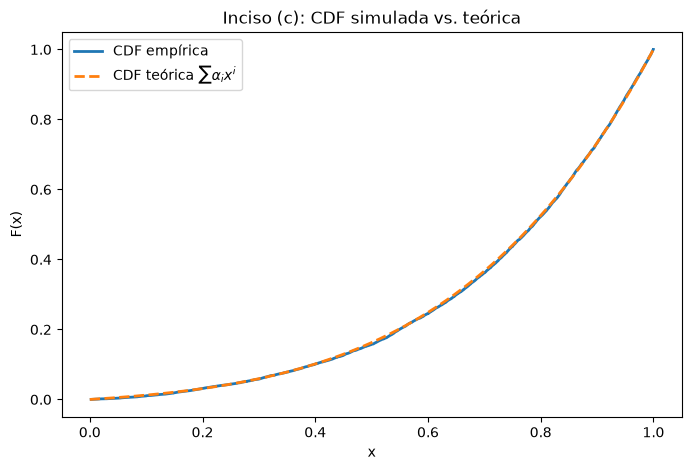

In [10]:
import numpy as np
import matplotlib.pyplot as plt

muestras_ordenadas = np.sort(muestras_del_inciso_c)
cdf_empirica = np.arange(1, numero_de_muestras + 1) / numero_de_muestras

puntos_x = np.linspace(0, 1, 300)
cdf_teorica = sum(
    alfa * puntos_x ** (indice + 1)
    for indice, alfa in enumerate(alfas_de_ejemplo)
)

plt.figure(figsize=(8, 5))
plt.plot(muestras_ordenadas, cdf_empirica, linewidth=2, label="CDF empírica")
plt.plot(puntos_x, cdf_teorica, linestyle="--", linewidth=2, label=r"CDF teórica $\sum \alpha_i x^i$")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Inciso (c): CDF simulada vs. teórica")
plt.legend()
plt.show()

## Ejercicio 4

Una compañía de seguros contra siniestros tiene 1000 asegurados, cada uno de los cuales presentará una reclamación en el próximo mes de manera independiente con probabilidad 0.05. Suponiendo que los montos de las reclamaciones son variables aleatorias exponenciales independientes con media \$800, utilice simulación para estimar la probabilidad de que la suma de estas reclamaciones exceda \$50,000.

Cada asegurado aporta al total de forma independiente en dos pasos: primero decide si reclama (Bernoulli con $p=0.05$) y, si reclama, el monto es $\text{Exp}$ de media 800, generado por transformada inversa:

$$\text{monto} = -800 \ln U$$

Sea $S$ la suma de los montos de un mes. Se quiere estimar $P(S > 50000)$, así que en cada réplica se registra el indicador

$$I = \mathbb{1}\{S > 50000\}$$

y se promedian los indicadores sobre muchas réplicas, ya que $E[I] = P(S>50000)$.

Como referencia, el número esperado de reclamos es $1000(0.05)=50$ y el total esperado es $50(800)=\$40{,}000$, por debajo del umbral.

In [11]:
import random
import math

random.seed(42)

numero_de_asegurados = 1000
probabilidad_de_reclamar = 0.05
media_del_monto_de_reclamacion = 800
umbral_de_reclamaciones = 50000
numero_de_replicas = 10000

def simular_un_mes():
    suma_de_reclamaciones_del_mes = 0.0

    for indice_de_asegurado in range(numero_de_asegurados):
        if random.random() < probabilidad_de_reclamar:
            numero_aleatorio_para_el_monto = random.random()
            monto_de_la_reclamacion = -media_del_monto_de_reclamacion * math.log(numero_aleatorio_para_el_monto)
            suma_de_reclamaciones_del_mes += monto_de_la_reclamacion

    return suma_de_reclamaciones_del_mes

sumas_de_cada_mes_simulado = [simular_un_mes() for _ in range(numero_de_replicas)]

meses_que_excedieron_el_umbral = sum(
    1 for suma in sumas_de_cada_mes_simulado if suma > umbral_de_reclamaciones
)
probabilidad_estimada = meses_que_excedieron_el_umbral / numero_de_replicas

error_estandar = math.sqrt(probabilidad_estimada * (1 - probabilidad_estimada) / numero_de_replicas)

print(f"Réplicas simuladas: {numero_de_replicas}")
print(f"Suma promedio de reclamaciones por mes: ${sum(sumas_de_cada_mes_simulado)/numero_de_replicas:,.2f}")
print(f"Meses que excedieron ${umbral_de_reclamaciones:,}: {meses_que_excedieron_el_umbral}")
print(f"Probabilidad estimada: {probabilidad_estimada:.4f}")
print(f"Error estándar: {error_estandar:.4f}")

Réplicas simuladas: 10000
Suma promedio de reclamaciones por mes: $40,000.37
Meses que excedieron $50,000: 1055
Probabilidad estimada: 0.1055
Error estándar: 0.0031


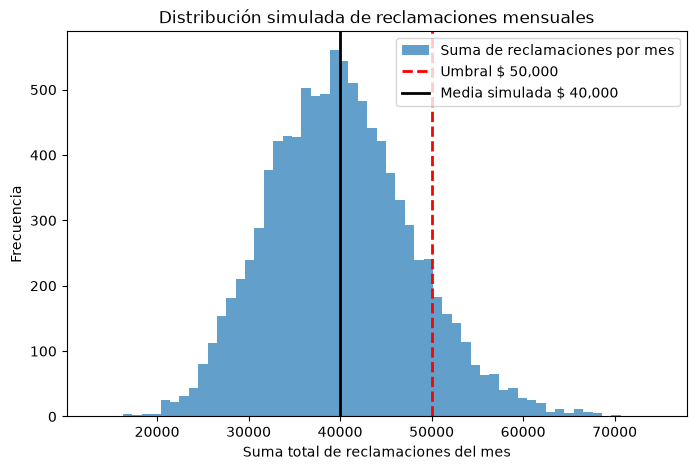

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(sumas_de_cada_mes_simulado, bins=60, alpha=0.7, label="Suma de reclamaciones por mes")
plt.axvline(umbral_de_reclamaciones, color="red", linestyle="--", linewidth=2,
            label=f"Umbral $ {umbral_de_reclamaciones:,}")
plt.axvline(np.mean(sumas_de_cada_mes_simulado), color="black", linewidth=2,
            label=f"Media simulada $ {np.mean(sumas_de_cada_mes_simulado):,.0f}")
plt.xlabel("Suma total de reclamaciones del mes")
plt.ylabel("Frecuencia")
plt.title("Distribución simulada de reclamaciones mensuales")
plt.legend()
plt.show()

## Ejercicio 5

Escriba un programa que genere variables aleatorias normales utilizando el método del Ejemplo 5f (método de rechazo con una distribución exponencial de tasa 1).

La acumulada de la normal no tiene forma cerrada, así que no se puede usar transformada inversa. En su lugar se genera primero el valor absoluto, cuya densidad es la mitad derecha con el doble de altura:

$$f(x) = \sqrt{\tfrac{2}{\pi}}\, e^{-x^2/2}, \quad x > 0$$

Como candidata se usa la exponencial de tasa 1, $g(x)=e^{-x}$, que es trivial de generar. La razón entre ambas

$$\frac{f(x)}{g(x)} = \sqrt{\tfrac{2}{\pi}}\, e^{\,x - x^2/2}$$

se maximiza donde $\frac{d}{dx}(x - x^2/2) = 1-x = 0$, es decir en $x=1$, lo que da la constante de cobertura

$$c = \frac{f(1)}{g(1)} = \sqrt{\tfrac{2e}{\pi}} \approx 1.3155$$

Con ese valor la probabilidad de aceptación se simplifica y queda sin raíces ni $\pi$:

$$\frac{f(x)}{c\,g(x)} = e^{-(x-1)^2/2}$$

Se genera $Y \sim \text{Exp}(1)$ y se acepta con esa probabilidad; si se rechaza se empieza de cero, a diferencia del adelgazamiento donde el reloj no retrocedía. El valor aceptado es $|Z|$, y el signo se decide con un aleatorio extra. En promedio se necesitan $c \approx 1.32$ intentos, o sea que se acepta el $1/c \approx 76\%$ de las veces.

La segunda versión toma logaritmo en la condición de aceptación:

$$U \le e^{-(Y_1-1)^2/2} \iff -\ln U \ge \frac{(Y_1-1)^2}{2}$$

Como $-\ln U$ es otra exponencial de tasa 1, la condición se vuelve $Y_2 \ge (Y_1-1)^2/2$, puro álgebra. Al aceptar, el sobrante $Y_2 - (Y_1-1)^2/2$ es una exponencial de tasa 1 independiente de la normal, que sale gratis y baja el costo neto a $2c-1 \approx 1.64$ exponenciales por normal.

In [ ]:
import random
import math

random.seed(42)

def generar_normal_estandar_por_rechazo():
    numero_de_intentos = 0

    while True:
        numero_de_intentos += 1
        numero_aleatorio_para_la_exponencial = random.random()
        candidato_exponencial = -math.log(numero_aleatorio_para_la_exponencial)

        probabilidad_de_aceptar = math.exp(-((candidato_exponencial - 1) ** 2) / 2)
        numero_aleatorio_para_aceptar = random.random()

        if numero_aleatorio_para_aceptar <= probabilidad_de_aceptar:
            valor_absoluto_de_la_normal = candidato_exponencial
            break

    numero_aleatorio_para_el_signo = random.random()
    if numero_aleatorio_para_el_signo <= 0.5:
        return valor_absoluto_de_la_normal, numero_de_intentos
    return -valor_absoluto_de_la_normal, numero_de_intentos

numero_de_normales_a_generar = 10000

resultados_de_la_version_1 = [generar_normal_estandar_por_rechazo() for _ in range(numero_de_normales_a_generar)]
normales_simuladas = [valor for valor, _ in resultados_de_la_version_1]
intentos_por_normal = [intentos for _, intentos in resultados_de_la_version_1]

media_simulada = sum(normales_simuladas) / numero_de_normales_a_generar
varianza_simulada = sum((valor - media_simulada) ** 2 for valor in normales_simuladas) / numero_de_normales_a_generar
intentos_promedio = sum(intentos_por_normal) / numero_de_normales_a_generar
constante_de_cobertura = math.sqrt(2 * math.e / math.pi)

print(f"Normales generadas: {numero_de_normales_a_generar}")
print(f"Media:    {media_simulada:.5f}  (teorica: 0)")
print(f"Varianza: {varianza_simulada:.5f}  (teorica: 1)")
print(f"Intentos promedio: {intentos_promedio:.5f}  (teorica c = {constante_de_cobertura:.5f})")
print(f"Proporcion aceptada: {1 / intentos_promedio:.5f}  (teorica 1/c = {1 / constante_de_cobertura:.5f})")
print(f"Primeras 8 normales: {[round(valor, 4) for valor in normales_simuladas[:8]]}")

In [ ]:
random.seed(42)

def generar_normal_y_exponencial():
    while True:
        primera_exponencial = -math.log(random.random())
        segunda_exponencial = -math.log(random.random())
        sobrante = segunda_exponencial - ((primera_exponencial - 1) ** 2) / 2

        if sobrante > 0:
            break

    numero_aleatorio_para_el_signo = random.random()
    if numero_aleatorio_para_el_signo <= 0.5:
        return primera_exponencial, sobrante
    return -primera_exponencial, sobrante

resultados_de_la_version_2 = [generar_normal_y_exponencial() for _ in range(numero_de_normales_a_generar)]
normales_de_la_version_2 = [normal for normal, _ in resultados_de_la_version_2]
exponenciales_de_regalo = [exponencial for _, exponencial in resultados_de_la_version_2]

media_de_la_version_2 = sum(normales_de_la_version_2) / numero_de_normales_a_generar
varianza_de_la_version_2 = sum((valor - media_de_la_version_2) ** 2 for valor in normales_de_la_version_2) / numero_de_normales_a_generar
media_de_las_exponenciales = sum(exponenciales_de_regalo) / numero_de_normales_a_generar

covarianza_entre_ambas = sum(
    (normal - media_de_la_version_2) * (exponencial - media_de_las_exponenciales)
    for normal, exponencial in resultados_de_la_version_2
) / numero_de_normales_a_generar

print(f"Media de la normal:      {media_de_la_version_2:.5f}  (teorica: 0)")
print(f"Varianza de la normal:   {varianza_de_la_version_2:.5f}  (teorica: 1)")
print(f"Media de la exponencial: {media_de_las_exponenciales:.5f}  (teorica: 1)")
print(f"Covarianza entre ambas:  {covarianza_entre_ambas:.5f}  (teorica: 0, son independientes)")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

figura, (eje_de_normales, eje_de_exponenciales) = plt.subplots(1, 2, figsize=(12, 5))

malla_de_normales = np.linspace(-4, 4, 400)
eje_de_normales.hist(normales_simuladas, bins=60, density=True, alpha=0.6, label="simuladas")
eje_de_normales.plot(
    malla_de_normales,
    np.exp(-malla_de_normales ** 2 / 2) / np.sqrt(2 * np.pi),
    linewidth=2,
    label="densidad N(0,1)",
)
eje_de_normales.set_title("Normales por rechazo")
eje_de_normales.legend()

malla_de_exponenciales = np.linspace(0, 7, 400)
eje_de_exponenciales.hist(exponenciales_de_regalo, bins=60, density=True, alpha=0.6, label="sobrantes")
eje_de_exponenciales.plot(
    malla_de_exponenciales,
    np.exp(-malla_de_exponenciales),
    linewidth=2,
    label="densidad Exp(1)",
)
eje_de_exponenciales.set_title("Exponenciales de regalo (version 2)")
eje_de_exponenciales.legend()

plt.tight_layout()
plt.show()

## Ejercicio 6

Escriba un programa que genere las primeras $T$ unidades de tiempo de un proceso de Poisson con tasa $\lambda$.

En un proceso de Poisson de tasa $\lambda$, los tiempos entre eventos consecutivos son $\text{Exp}(\lambda)$ independientes, así que cada hueco se genera por transformada inversa:

$$\text{hueco} = -\frac{\ln U}{\lambda}$$

Partiendo de $t=0$ se van acumulando huecos y se registra cada tiempo alcanzado, hasta que un salto pase de $T$ (ese último ya cae fuera de la ventana y se descarta).

El número de eventos no se fija de antemano: también es aleatorio, con media $\lambda T$.

In [13]:
import random
import math

random.seed(42)

def simular_proceso_de_poisson(tasa_de_eventos, tiempo_maximo):
    tiempos_de_los_eventos = []
    tiempo_actual = 0.0

    while True:
        numero_aleatorio_para_el_hueco = random.random()
        hueco_hasta_el_siguiente_evento = -math.log(numero_aleatorio_para_el_hueco) / tasa_de_eventos
        tiempo_actual += hueco_hasta_el_siguiente_evento

        if tiempo_actual >= tiempo_maximo:
            break

        tiempos_de_los_eventos.append(tiempo_actual)

    return tiempos_de_los_eventos

tasa_de_ejemplo = 3
tiempo_maximo_de_ejemplo = 10

eventos_simulados = simular_proceso_de_poisson(tasa_de_ejemplo, tiempo_maximo_de_ejemplo)

print(f"Tasa lambda = {tasa_de_ejemplo}, ventana T = {tiempo_maximo_de_ejemplo}")
print(f"Eventos generados: {len(eventos_simulados)}  (esperados en promedio: {tasa_de_ejemplo * tiempo_maximo_de_ejemplo})")
print(f"Primeros 10 tiempos: {[round(t, 4) for t in eventos_simulados[:10]]}")

Tasa lambda = 3, ventana T = 10
Eventos generados: 19  (esperados en promedio: 30)
Primeros 10 tiempos: [0.1491, 1.3785, 1.8088, 2.3087, 2.4107, 2.5409, 2.5789, 3.3931, 3.6807, 4.8518]


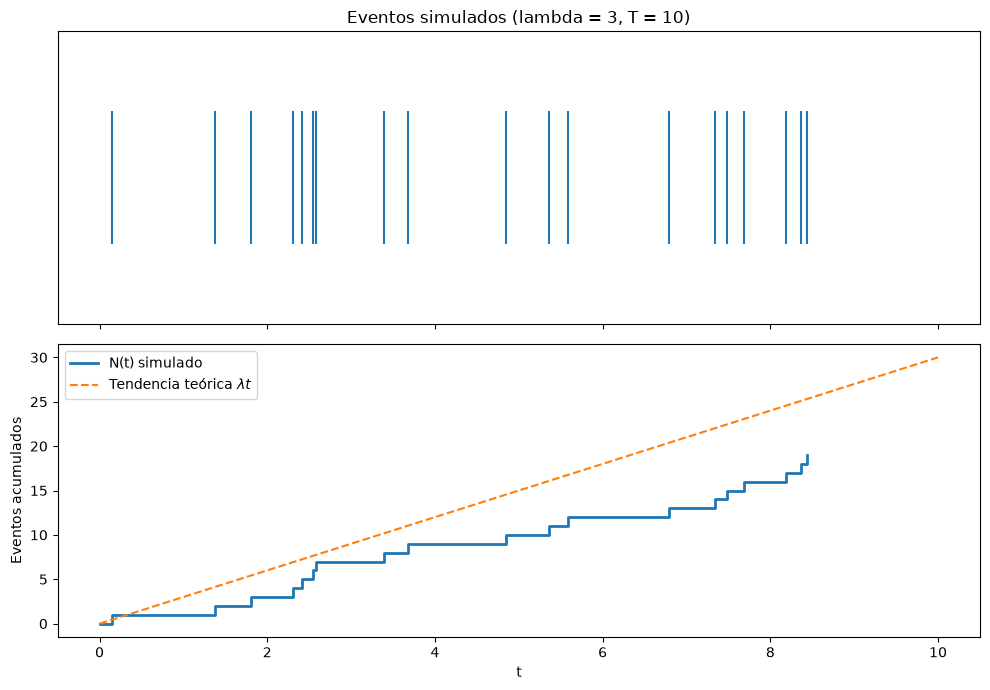

In [14]:
import numpy as np
import matplotlib.pyplot as plt

figura, (eje_de_eventos, eje_de_conteo) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

eje_de_eventos.eventplot(eventos_simulados, colors="tab:blue", lineoffsets=0, linelengths=1)
eje_de_eventos.set_yticks([])
eje_de_eventos.set_title(f"Eventos simulados (lambda = {tasa_de_ejemplo}, T = {tiempo_maximo_de_ejemplo})")

eje_de_conteo.step(
    [0] + eventos_simulados,
    range(len(eventos_simulados) + 1),
    where="post",
    linewidth=2,
    label="N(t) simulado",
)
eje_de_conteo.plot(
    [0, tiempo_maximo_de_ejemplo],
    [0, tasa_de_ejemplo * tiempo_maximo_de_ejemplo],
    linestyle="--",
    label="Tendencia teórica $\\lambda t$",
)
eje_de_conteo.set_xlabel("t")
eje_de_conteo.set_ylabel("Eventos acumulados")
eje_de_conteo.legend()

plt.tight_layout()
plt.show()

## Ejercicio 7

(a) Escriba un programa que utilice el algoritmo de adelgazamiento (thinning) para generar las primeras 10 unidades de tiempo de un proceso de Poisson no homogéneo con función de intensidad

$$\lambda(t) = 3 + \frac{4}{t+1}$$

La intensidad $\lambda(t) = 3 + \frac{4}{t+1}$ es decreciente, así que su valor máximo está en $t=0$ y sirve como techo constante:

$$\lambda^* = \lambda(0) = 7 \ \ge\ \lambda(t) \quad \text{para todo } t \ge 0$$

Con ese techo se simula un proceso homogéneo de tasa $\lambda^*$ (huecos $\text{Exp}(\lambda^*)$, igual que en el ejercicio 6), que genera candidatos de más. Cada candidato que cae en el instante $t$ se conserva con probabilidad

$$\frac{\lambda(t)}{\lambda^*}$$

usando un segundo número aleatorio. Los rechazados se descartan sin retroceder el reloj: solo se pierde el punto, no el tiempo transcurrido. Como la tasa de sobrevivientes es $\lambda^* \cdot \frac{\lambda(t)}{\lambda^*} = \lambda(t)$, el resultado es exacto.

Se esperan $\lambda^* T = 70$ candidatos, de los cuales sobreviven en promedio

$$m(T) = \int_0^{10}\left(3 + \frac{4}{t+1}\right)dt = 30 + 4\ln(11) \approx 39.59$$

In [ ]:
import random
import math

random.seed(42)

def funcion_de_intensidad(tiempo):
    return 3 + 4 / (tiempo + 1)

def simular_proceso_no_homogeneo(intensidad, tasa_techo, tiempo_maximo):
    tiempos_aceptados = []
    tiempos_rechazados = []
    tiempo_actual = 0.0

    while True:
        numero_aleatorio_para_el_hueco = random.random()
        hueco_hasta_el_siguiente_candidato = -math.log(numero_aleatorio_para_el_hueco) / tasa_techo
        tiempo_actual += hueco_hasta_el_siguiente_candidato

        if tiempo_actual >= tiempo_maximo:
            break

        probabilidad_de_aceptar = intensidad(tiempo_actual) / tasa_techo
        numero_aleatorio_para_aceptar = random.random()

        if numero_aleatorio_para_aceptar <= probabilidad_de_aceptar:
            tiempos_aceptados.append(tiempo_actual)
        else:
            tiempos_rechazados.append(tiempo_actual)

    return tiempos_aceptados, tiempos_rechazados

tasa_techo = funcion_de_intensidad(0)
tiempo_maximo_de_ejemplo = 10

eventos_aceptados, candidatos_rechazados = simular_proceso_no_homogeneo(
    funcion_de_intensidad, tasa_techo, tiempo_maximo_de_ejemplo
)

total_de_candidatos = len(eventos_aceptados) + len(candidatos_rechazados)
eventos_esperados = 3 * tiempo_maximo_de_ejemplo + 4 * math.log(tiempo_maximo_de_ejemplo + 1)

print(f"Techo lambda* = {tasa_techo}, ventana T = {tiempo_maximo_de_ejemplo}")
print(f"Candidatos generados: {total_de_candidatos}  (esperados: {tasa_techo * tiempo_maximo_de_ejemplo:.0f})")
print(f"Eventos aceptados:    {len(eventos_aceptados)}  (esperados: {eventos_esperados:.2f})")
print(f"Proporcion aceptada:  {len(eventos_aceptados) / total_de_candidatos:.4f}")
print(f"Primeros 10 tiempos: {[round(t, 4) for t in eventos_aceptados[:10]]}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

malla_de_tiempo = np.linspace(0, tiempo_maximo_de_ejemplo, 400)

figura, (eje_de_intensidad, eje_de_marcas, eje_de_conteo) = plt.subplots(
    3, 1, figsize=(10, 9), sharex=True, height_ratios=[2, 1, 2]
)

eje_de_intensidad.plot(malla_de_tiempo, 3 + 4 / (malla_de_tiempo + 1), linewidth=2, label="$\\lambda(t)$")
eje_de_intensidad.axhline(tasa_techo, linestyle="--", color="gray", label="techo $\\lambda^*=7$")
eje_de_intensidad.set_ylabel("Intensidad")
eje_de_intensidad.set_ylim(0, 8)
eje_de_intensidad.legend()

eje_de_marcas.eventplot(eventos_aceptados, colors="tab:green", lineoffsets=1, linelengths=0.8)
eje_de_marcas.eventplot(candidatos_rechazados, colors="tab:red", lineoffsets=0, linelengths=0.8)
eje_de_marcas.set_yticks([0, 1])
eje_de_marcas.set_yticklabels(["rechazados", "aceptados"])

eje_de_conteo.step(
    [0] + eventos_aceptados,
    range(len(eventos_aceptados) + 1),
    where="post",
    linewidth=2,
    label="N(t) simulado",
)
eje_de_conteo.plot(
    malla_de_tiempo,
    3 * malla_de_tiempo + 4 * np.log(malla_de_tiempo + 1),
    linestyle="--",
    label="$m(t)=3t+4\\ln(t+1)$",
)
eje_de_conteo.set_xlabel("t")
eje_de_conteo.set_ylabel("Eventos acumulados")
eje_de_conteo.legend()

plt.tight_layout()
plt.show()

(b) Proponga una manera de mejorar el algoritmo de adelgazamiento para este ejemplo.

El problema del algoritmo anterior es que usa un solo techo, $\lambda^*=7$, durante toda la ventana. Ese valor solo se justifica en $t=0$, porque la intensidad cae rápido: en $t=1$ ya vale 5 y de $t=3$ en adelante nunca pasa de 4. Después del arranque estamos generando candidatos al ritmo del peor caso y tirando casi la mitad.

La mejora es partir $[0,10]$ en tramos y darle a cada uno su propio techo, el máximo de $\lambda(t)$ dentro de ese tramo. Como la intensidad es decreciente, ese máximo siempre está al inicio del tramo:

| tramo | techo | candidatos esperados |
|---|---|---|
| $[0,1)$ | $\lambda(0)=7$ | 7 |
| $[1,3)$ | $\lambda(1)=5$ | 10 |
| $[3,10)$ | $\lambda(3)=4$ | 28 |
| | | **45** |

El techo baja escalonadamente siguiendo a la curva en vez de quedarse pegado arriba. Los eventos aceptados no cambian, siguen siendo $m(10)=30+4\ln(11)\approx 39.59$, porque eso lo fija la intensidad real y no el techo. Lo que cambia es el trabajo desperdiciado: se pasa de 70 candidatos a 45, y la proporción aceptada sube de 57% a 88%.

Al cruzar la frontera de un tramo se descarta el salto que se pasó y se reinicia el reloj ahí con el techo nuevo, lo cual es válido porque el proceso de Poisson no tiene memoria.

Más tramos dan techos más pegados a la curva y menos desperdicio, pero también más código y más control de fronteras. Con tres tramos ya se recupera casi toda la ganancia posible, así que no vale la pena refinar más.

La alternativa sin ningún rechazo es invertir la intensidad acumulada $m(t)=3t+4\ln(t+1)$, generar un proceso homogéneo de tasa 1 y transformar cada tiempo con $m^{-1}$. Eso acepta el 100% de los puntos, pero $m$ no se puede invertir con álgebra y habría que resolverla numéricamente en cada evento. Se cambia desperdicio por cálculo numérico, y para este caso los techos por tramos son la opción más sencilla y suficiente.

## Ejercicio 8

Escriba un programa para generar los puntos de un proceso de Poisson bidimensional dentro de un círculo de radio $R$, y ejecute el programa para $\lambda = 1$ y $R = 5$. Grafique los puntos obtenidos.

## Material de apoyo: Ejemplo 5f — Generación de una variable aleatoria normal

Para generar una variable aleatoria normal estándar $Z$ (es decir, con media 0 y varianza 1), se observa primero que el valor absoluto de $Z$ tiene función de densidad

$$f(x) = \sqrt{\frac{2}{\pi}}\, e^{-x^2/2}, \quad 0 < x < \infty$$

Esta densidad se genera usando el método de rechazo, tomando como densidad auxiliar $g$ la exponencial de media 1, es decir $g(x) = e^{-x}$, $0 < x < \infty$. Entonces

$$\frac{f(x)}{g(x)} = \sqrt{2/\pi}\; e^{\,x - x^2/2}$$

cuyo máximo ocurre en $x=1$, lo que da la constante

$$c = \max_x \frac{f(x)}{g(x)} = \frac{f(1)}{g(1)} = \sqrt{2e/\pi}$$

Como $\dfrac{f(x)}{c\,g(x)} = \exp\left\{-\dfrac{(x-1)^2}{2}\right\}$, se obtiene el siguiente algoritmo para generar el valor absoluto de una normal estándar:

- **Paso 1:** Genere $Y$, una exponencial con tasa 1.
- **Paso 2:** Genere un número aleatorio $U$.
- **Paso 3:** Si $U \le \exp\{-(Y-1)^2/2\}$, haga $X=Y$. En caso contrario, regrese al Paso 1.

Una vez generado $X$ (que se distribuye como el valor absoluto de una normal estándar), se obtiene $Z$ haciendo que sea igualmente probable que valga $X$ o $-X$ (esto se decide con un número aleatorio adicional: si $U \le 1/2$ entonces $Z=X$; si no, $Z=-X$).

Puede demostrarse además que la condición de aceptación del Paso 3 es equivalente a $-\log U \ge (Y-1)^2/2$, y como $-\log U$ es exponencial de tasa 1, se obtiene la siguiente versión equivalente, que genera simultáneamente una normal estándar y — como subproducto — una exponencial independiente de tasa 1:

- **Paso 1:** Genere $Y_1$, exponencial con tasa 1.
- **Paso 2:** Genere $Y_2$, exponencial con tasa 1.
- **Paso 3:** Si $Y_2-(Y_1-1)^2/2 > 0$, haga $Y = Y_2-(Y_1-1)^2/2$ y continúe al Paso 4. En caso contrario, regrese al Paso 1.
- **Paso 4:** Genere un número aleatorio $U$ y haga

$$Z = \begin{cases} Y_1 & \text{si } U \le 1/2 \\ -Y_1 & \text{si } U > 1/2 \end{cases}$$

$Z$ (normal estándar) e $Y$ (exponencial de tasa 1) resultan independientes. Dado que $c=\sqrt{2e/\pi}\approx 1.32$, en promedio el algoritmo requiere generar 1.64 exponenciales y calcular 1.32 cuadrados por cada normal generada. (Si se desea una normal de media $\mu$ y varianza $\sigma^2$, basta con tomar $\mu+\sigma Z$.)

## Ejercicio 9

Explique el método polar para generar variables aleatorias normales. Su explicación debe incluir:

(a) En qué consiste el método (idea general y algoritmo paso a paso).

*(Respuesta aquí)*

(b) Para qué sirve (qué problema resuelve y por qué es preferible frente al uso directo de las transformaciones de Box–Muller).

*(Respuesta aquí)*

(c) Un ejemplo numérico: elija valores de $U_1$ y $U_2$ y aplique el algoritmo paso a paso hasta obtener el par de normales $X, Y$ (si el primer par $(V_1, V_2)$ cae fuera del círculo unitario, elija un segundo par y continúe).

## Ejercicio 10

Explique el proceso de Poisson bidimensional y el algoritmo para simularlo dentro de una región circular. Su explicación debe incluir:

(a) En qué consiste (definición formal del proceso y el algoritmo de simulación paso a paso).

*(Respuesta aquí)*

(b) Para qué sirve (qué tipo de fenómenos se pueden modelar con este proceso y por qué es útil poder simularlo).

*(Respuesta aquí)*

(c) Un ejemplo numérico: para $\lambda=1$ y $r=2$, elija valores de $X_1, X_2, \ldots$ (o de los números aleatorios necesarios para generarlos) y aplique el algoritmo paso a paso hasta obtener las coordenadas polares de los puntos simulados.